## Model Calibration

### What is model calibration?

Model calibration refers to the process of aligning a model’s **predicted probabilities** with the **true observed frequencies** of the event of interest.

In a well-calibrated model:
- Among all observations predicted with a 20% probability of default (PD),
- Approximately 20% should actually default.

It is important to distinguish between:
- **Ranking performance** (e.g. ROC-AUC, PR-AUC): how well the model orders borrowers by risk.
- **Probability calibration**: how accurate the predicted probabilities are in absolute terms.

A model can rank borrowers correctly while still producing poorly calibrated probabilities.


### Why calibration matters in credit risk

In credit risk modeling, predictions are not used as binary classifications, but as **probability of default (PD)** estimates.

Well-calibrated probabilities are required to support:
- Credit approval and rejection cut-offs,
- Risk-based pricing strategies,
- Portfolio-level expected loss estimation,
- Monitoring predicted vs realized default rates over time.

Without calibration, model outputs may be directionally correct but **not actionable for business decisions**.


### Why calibration can be applied at this stage

Model calibration is applied only after the following conditions are met:

- The target variable represents a **meaningful and observable risk event**.
- The model shows **reasonable discriminatory power** (i.e. it separates high-risk from low-risk borrowers).
- The modeling objective has shifted from improving ranking to **producing reliable PD estimates**.

After redefining the target variable and resolving extreme class imbalance, these conditions are now satisfied.  
Calibrating earlier would not have added value, as the underlying probabilities would not have been economically meaningful.


### Common calibration methods

Several calibration techniques are commonly used in practice:

#### 1. Platt Scaling (Logistic Calibration)
- Fits a logistic regression on top of the model’s raw scores.
- Assumes a sigmoid relationship between scores and true probabilities.
- Stable, interpretable, and widely used in credit risk.

#### 2. Isotonic Regression
- Non-parametric, monotonic calibration method.
- More flexible than Platt scaling.
- Higher risk of overfitting, especially on smaller datasets.

#### 3. Temperature Scaling
- Primarily used in deep learning contexts.
- Less common in traditional credit scoring applications.


### Calibration approach used in this project

In this project, **Platt Scaling** is used as the primary calibration method.

The reasons for this choice are:
- The underlying models produce relatively smooth probability estimates.
- The dataset size favors a stable, low-variance calibration method.
- Platt scaling is easy to interpret and aligns well with industry practice in credit risk.

**Isotonic regression** is used as a secondary comparison to validate that calibration improvements are not model-specific or accidental.


### Evaluation of calibration quality

Calibration quality is assessed using:
- **Calibration curves** (predicted vs observed default rates),
- **Brier score**, which measures the accuracy of probabilistic predictions.

These metrics complement traditional discrimination metrics and provide insight into whether predicted PDs can be trusted for downstream business decisions.

## Gameplan

1. Data Splits for Calibration
2. Baseline: Uncalibrated Probabilities
3. Calibration Methods: Platt Scaling
4. Calibration Methods: Isotonic Regression
5. Calibration Performance Comparison

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score
from sklearn.impute import SimpleImputer

In [26]:
df = pd.read_csv('loans_full_schema.csv')

default_status = [
    "Charged Off",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)"
]

non_default_status = ["Fully Paid"]

df_pd = df.loc[
    df["loan_status"].isin(default_status + non_default_status)
].copy()

# Binary target: 1 = default-like, 0 = non-default
df_pd["default"] = df_pd["loan_status"].isin(default_status).astype(int)


# Selected features based on EDA + credit intuition
num_features = [
    # Financial capacity
    "annual_income",
    "annual_income_joint",
    "debt_to_income",

    
    # Employment stability
    "emp_length",
    
    # Credit history & structure
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts",

    # Past delinquency / adverse events
    "months_since_last_delinq",
    
    # Loan characteristics
    "loan_amount",
    
]

cat_features = [
    "homeownership",
    "verified_income",
    "public_record_bankrupt",
    "tax_liens",
    "loan_purpose",
    "application_type",
    "state",
    "emp_title"
]

features = num_features + cat_features

df_model = df_pd[features + ["loan_status"]].copy()

vars_to_scale = [
    "annual_income",
    "annual_income_joint",
    "emp_length",
    "earliest_credit_line",
    "total_credit_lines",
    "open_credit_lines",
    "total_debit_limit",
    "num_total_cc_accounts",
    "num_open_cc_accounts",
    "months_since_last_delinq",
    "loan_amount",
    # Key: debt_to_income out of the scaler because it is a ratio
    "debt_to_income"
]

target = "default"

X = df_pd[vars_to_scale+cat_features].copy()
y = df_pd[target]
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42, stratify=y
)

def compute_loan_income_ratio(df):
    income = df["annual_income"].copy()
    mask = (income.isna()) | (income <= 0)
    income[mask] = df.loc[mask, "annual_income_joint"]

    ratio = df["loan_amount"] / income
    return ratio

# Create ratio
X_train["loan_to_income_ratio"] = compute_loan_income_ratio(X_train)
X_test["loan_to_income_ratio"]  = compute_loan_income_ratio(X_test)

# Drop rows where ratio could not be computed
train_mask = X_train["loan_to_income_ratio"].notna()
test_mask  = X_test["loan_to_income_ratio"].notna()

X_train = X_train.loc[train_mask].copy()
y_train = y_train.loc[train_mask].copy()

X_test  = X_test.loc[test_mask].copy()
y_test  = y_test.loc[test_mask].copy()

vars_to_scale.append("loan_to_income_ratio")
vars_not_scale = ["debt_to_income"]

# ColumnTransformer: scale only selected numeric columns
scaler_num_var = ColumnTransformer(
    transformers=[
        ("vars_to_scale",StandardScaler(),vars_to_scale),
        ("num_passthrough","passthrough", vars_not_scale),
        ("cat_passthrough", "passthrough", cat_features)
    ]
)

# Fit ONLY on train, then transform both train and test
X_train_scaled = scaler_num_var.fit_transform(X_train)
X_test_scaled = scaler_num_var.transform(X_test) 

# ColumnTransformer: scale only selected numeric columns
preprocess = ColumnTransformer(
    transformers=[
        ("vars_to_scale",StandardScaler(),vars_to_scale),
        ("num_passthrough","passthrough", vars_not_scale),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="drop"
)

X_train_preprocessed = preprocess.fit_transform(X_train)
X_test_preprocessed = preprocess.transform(X_test) 

In [27]:
# 1. Data Splits for Calibration

# We already have:
#   X_train, X_test, y_train, y_test
# where X_test/y_test is our final holdout set.
#
# For calibration we must create a *separate* calibration (validation) set
# from the training data only. The test set must remain untouched.

X_train, X_cal, y_train, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.20,          # 20% of the training data reserved for calibration
    stratify=y_train,
    random_state=42
)

print("Shapes after creating calibration split:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_cal  : {X_cal.shape}   | y_cal  : {y_cal.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

print("\nDefault rate (mean of y) per split:")
print(f"Train: {y_train.mean():.4f}")
print(f"Cal  : {y_cal.mean():.4f}")
print(f"Test : {y_test.mean():.4f}")


Shapes after creating calibration split:
X_train: (400, 21) | y_train: (400,)
X_cal  : (100, 21)   | y_cal  : (100,)
X_test : (125, 21)  | y_test : (125,)

Default rate (mean of y) per split:
Train: 0.2850
Cal  : 0.2800
Test : 0.2880


In [28]:
X_train_preprocessed = preprocess.fit_transform(X_train)
X_cal_preprocessed = preprocess.transform(X_cal)
X_test_preprocessed = preprocess.transform(X_test)

print("\nPreprocessed matrices:")
print(f"X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"X_cal_preprocessed  : {X_cal_preprocessed.shape}")
print(f"X_test_preprocessed : {X_test_preprocessed.shape}")


Preprocessed matrices:
X_train_preprocessed: (400, 408)
X_cal_preprocessed  : (100, 408)
X_test_preprocessed : (125, 408)


In [ ]:
# 2. Baseline: Uncalibrated Probabilities

# Train a base classifier and inspect probability quality BEFORE calibration.
# We evaluate on:
# - Calibration set (X_cal_preprocessed): to understand baseline miscalibration
# - Test set (X_test_preprocessed): final untouched evaluation reference

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

# 2.1 Train baseline model
imputer = SimpleImputer(strategy="median")
X_train_preprocessed = imputer.fit_transform(X_train_preprocessed)
X_cal_preprocessed   = imputer.transform(X_cal_preprocessed)
X_test_preprocessed  = imputer.transform(X_test_preprocessed)


baseline_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

"""
If preprocessing is inside a Pipeline → you fit on X_train (raw).
If preprocessing is done outside the model → you fit on X_train_preprocessed.
"""
baseline_lr.fit(X_train_preprocessed, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### Why we fit the model on `X_train_preprocessed`

In this notebook, preprocessing is performed **outside** the estimator using a dedicated transformation step (`preprocess`).  
Therefore, the classifier is trained on the **transformed feature matrix** (`X_train_preprocessed`), not on the raw input `X_train`.

This approach is methodologically correct because the model expects a fully numeric, consistent representation where:
- categorical features have already been encoded (e.g., one-hot),
- numerical features have been scaled when needed,
- missing values have been handled (via imputation).

To avoid data leakage, all preprocessing steps are **fitted only on the training split** and then applied to the calibration and test splits using `.transform()` only.  
This mimics real deployment: at prediction time we observe raw applicant data, apply the same fixed preprocessing, and then score the model.

> Note: An equivalent alternative is to wrap preprocessing and the model inside a single `Pipeline` and fit on raw `X_train` (done in model selection).  
> Here we keep preprocessing explicit for transparency and to inspect intermediate matrices during calibration.


In [35]:

# Predicted probabilities (uncalibrated)
p_cal_uncal  = baseline_lr.predict_proba(X_cal_preprocessed)[:, 1]
p_test_uncal = baseline_lr.predict_proba(X_test_preprocessed)[:, 1]

# Metrics
print("Uncalibrated probability metrics:")
print(f"Brier score | Cal:  {brier_score_loss(y_cal, p_cal_uncal):.5f}")
print(f"Brier score | Test: {brier_score_loss(y_test, p_test_uncal):.5f}")
print(f"ROC-AUC     | Cal:  {roc_auc_score(y_cal, p_cal_uncal):.5f}")
print(f"ROC-AUC     | Test: {roc_auc_score(y_test, p_test_uncal):.5f}")
print(f"PR-AUC      | Cal:  {average_precision_score(y_cal, p_cal_uncal):.5f}")
print(f"PR-AUC      | Test: {average_precision_score(y_test, p_test_uncal):.5f}")


Uncalibrated probability metrics:
Brier score | Cal:  0.23617
Brier score | Test: 0.25897
ROC-AUC     | Cal:  0.60813
ROC-AUC     | Test: 0.57022
PR-AUC      | Cal:  0.38960
PR-AUC      | Test: 0.32516


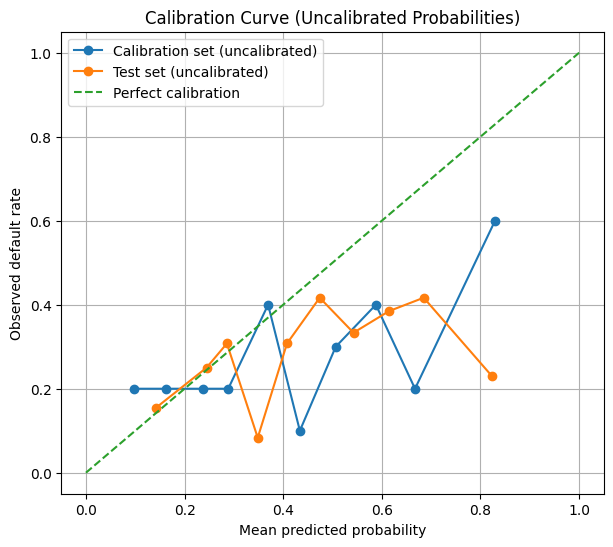

In [36]:
# Calibration curves
n_bins = 10
frac_pos_cal, mean_pred_cal = calibration_curve(y_cal, p_cal_uncal, n_bins=n_bins, strategy="quantile")
frac_pos_test, mean_pred_test = calibration_curve(y_test, p_test_uncal, n_bins=n_bins, strategy="quantile")

plt.figure(figsize=(7, 6))
plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="Calibration set (uncalibrated)")
plt.plot(mean_pred_test, frac_pos_test, marker="o", label="Test set (uncalibrated)")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Curve (Uncalibrated Probabilities)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of Uncalibrated Results

At this stage, the results should be interpreted with the understanding that **probabilities have not yet been calibrated**.

The model shows **moderate discriminatory power**, as indicated by ROC-AUC values slightly above 0.5 on both the calibration and test sets. This suggests the model is able to rank borrowers by relative risk better than random, although separation between default and non-default cases remains limited.

However, the **Brier scores are relatively high**, and the calibration curve shows clear deviations from the diagonal. This confirms that the raw probability outputs **should not be interpreted as true probabilities of default**.

This behavior is expected: many classification models are optimized for ranking rather than probability accuracy. At this stage, the model is suitable for **risk ordering**, but not yet for **decision-making based on absolute PD levels**, which motivates the need for explicit calibration.


Brier score comparison (lower is better):
Calibration set | Uncal: 0.23617 -> Platt: 0.20071
Test set        | Uncal: 0.25897 -> Platt: 0.20417


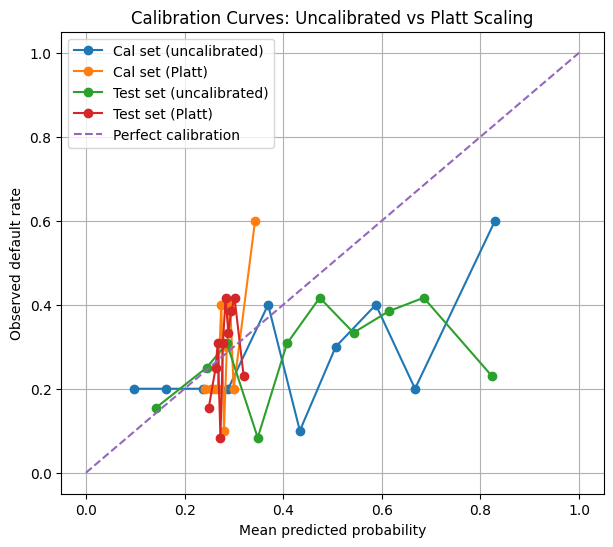

In [ ]:
# 3. Calibration Methods: Platt Scaling
# Platt scaling is literally a logistic regression that maps model scores --> calibrated probabilities

# 3.1 Fit Platt scaling on the calibration set
# # Convert probabilities to logits for a stable Platt mapping
# # logit(p) = log(p / (1-p))
eps = 1e-15
p_cal_clipped = np.clip(p_cal_uncal, eps, 1 - eps)
logit_cal = np.log(p_cal_clipped / (1 - p_cal_clipped)).reshape(-1, 1)

# Fit Platt scaler on calibration data
platt_scaler = LogisticRegression(max_iter=2000, random_state=42)
platt_scaler.fit(logit_cal, y_cal)

# 3.2 Apply Platt scaling to calibration and test probabilities
p_cal_calibrated = platt_scaler.predict_proba(logit_cal)[:, 1]

# Apply Platt scaler to test set
p_test_clipped = np.clip(p_test_uncal, eps, 1 - eps)
logit_test = np.log(p_test_clipped / (1 - p_test_clipped)).reshape(-1, 1)
p_test_calibrated = platt_scaler.predict_proba(logit_test)[:, 1]

# 3.3 Evaluation 
# # Brier score (lower is better)
# # calibration curve alignment (closer to diagonal)
# --- Brier scores ---
brier_cal_uncal = brier_score_loss(y_cal, p_cal_uncal)
brier_test_uncal = brier_score_loss(y_test, p_test_uncal)

brier_cal_cal = brier_score_loss(y_cal, p_cal_calibrated)
brier_test_cal = brier_score_loss(y_test, p_test_calibrated)

print("Brier score comparison (lower is better):")
print(f"Calibration set | Uncal: {brier_cal_uncal:.5f} -> Platt: {brier_cal_cal:.5f}")
print(f"Test set        | Uncal: {brier_test_uncal:.5f} -> Platt: {brier_test_cal:.5f}")

# --- Calibration curves ---
n_bins = 10

# Uncalibrated --> u // Calibrated --> c
frac_pos_cal_u, mean_pred_cal_u = calibration_curve(y_cal, p_cal_uncal, n_bins=n_bins, strategy="quantile")
frac_pos_cal_c, mean_pred_cal_c = calibration_curve(y_cal, p_cal_calibrated, n_bins=n_bins, strategy="quantile")

frac_pos_test_u, mean_pred_test_u = calibration_curve(y_test, p_test_uncal, n_bins=n_bins, strategy="quantile")
frac_pos_test_c, mean_pred_test_c = calibration_curve(y_test, p_test_calibrated, n_bins=n_bins, strategy="quantile")

plt.figure(figsize=(7, 6))
plt.plot(mean_pred_cal_u, frac_pos_cal_u, marker="o", label="Cal set (uncalibrated)")
plt.plot(mean_pred_cal_c, frac_pos_cal_c, marker="o", label="Cal set (Platt)")

plt.plot(mean_pred_test_u, frac_pos_test_u, marker="o", label="Test set (uncalibrated)")
plt.plot(mean_pred_test_c, frac_pos_test_c, marker="o", label="Test set (Platt)")

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Curves: Uncalibrated vs Platt Scaling")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.legend()
plt.grid(True)
plt.show()



## Results: Platt Scaling Calibration

Applying Platt scaling leads to a **clear improvement in probability accuracy**.

The Brier score decreases substantially after calibration:
- **Calibration set:** 0.236 --> 0.201  
- **Test set:** 0.259 --> 0.204  

This confirms that Platt scaling successfully corrects systematic miscalibration in the raw model outputs, and that the improvement **generalizes to unseen data**.

The calibration curves show that calibrated probabilities lie **closer to the diagonal**, particularly in the low-to-mid probability range where most observations lie.  
High-probability regions remain noisy, which is expected given the limited sample size and rarity of default events.

Importantly, calibration improves **probability reliability without changing ranking performance**.  

After Platt scaling, model outputs can be interpreted as **meaningful probability of default (PD) estimates**, making them suitable for downstream credit risk decisions such as cut-offs, pricing, and portfolio monitoring.


Brier score comparison (lower is better):
Calibration set | Uncal: 0.23617 -> Isotonic: 0.18535
Test set        | Uncal: 0.25897 -> Isotonic: 0.22232


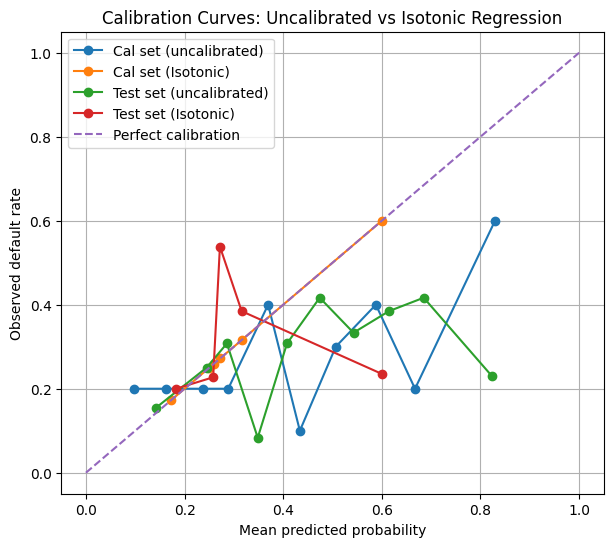

In [38]:
# 4. Calibration Methods: Isotonic Regression
from sklearn.isotonic import IsotonicRegression

iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(p_cal_uncal, y_cal)

# Calibrated probabilities (isotonic)
p_cal_iso = iso_reg.transform(p_cal_uncal)
p_test_iso = iso_reg.transform(p_test_uncal)


# --- Brier scores ---
brier_cal_iso = brier_score_loss(y_cal, p_cal_iso)
brier_test_iso = brier_score_loss(y_test, p_test_iso)

print("Brier score comparison (lower is better):")
print(f"Calibration set | Uncal: {brier_cal_uncal:.5f} -> Isotonic: {brier_cal_iso:.5f}")
print(f"Test set        | Uncal: {brier_test_uncal:.5f} -> Isotonic: {brier_test_iso:.5f}")

# --- Calibration curves ---
n_bins = 10

frac_pos_cal_i, mean_pred_cal_i = calibration_curve(
    y_cal, p_cal_iso, n_bins=n_bins, strategy="quantile"
)
frac_pos_test_i, mean_pred_test_i = calibration_curve(
    y_test, p_test_iso, n_bins=n_bins, strategy="quantile"
)

plt.figure(figsize=(7, 6))
plt.plot(mean_pred_cal_u, frac_pos_cal_u, marker="o", label="Cal set (uncalibrated)")
plt.plot(mean_pred_cal_i, frac_pos_cal_i, marker="o", label="Cal set (Isotonic)")

plt.plot(mean_pred_test_u, frac_pos_test_u, marker="o", label="Test set (uncalibrated)")
plt.plot(mean_pred_test_i, frac_pos_test_i, marker="o", label="Test set (Isotonic)")

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Curves: Uncalibrated vs Isotonic Regression")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.legend()
plt.grid(True)
plt.show()


## Results: Isotonic Regression Calibration

Isotonic regression leads to a **strong improvement in probability accuracy** on the calibration set.

The Brier score decreases substantially:
- **Calibration set:** 0.236 --> 0.185  
- **Test set:** 0.259 --> 0.222  

This confirms that isotonic regression is able to closely fit the observed default frequencies in the calibration data.

However, the calibration curves show a **more irregular shape**, particularly on the test set, with sharp adjustments in certain probability regions. This behavior reflects the higher flexibility of isotonic regression and suggests a greater risk of **overfitting**, especially given the limited sample size.

From a modeling perspective, isotonic regression achieves better in-sample calibration but exhibits **less stable generalization** compared to Platt scaling


## 5. Calibration Performance Comparison and Final Choice

Both calibration methods improve probability accuracy relative to the uncalibrated model.

- **Platt scaling** reduces the Brier score on both the calibration and test sets while producing smooth and stable calibration curves.
- **Isotonic regression** achieves stronger in-sample calibration but shows more irregular behavior on the test set, reflecting higher variance and a greater risk of overfitting.

Given the limited dataset size and the need for robust out-of-sample performance, **Platt scaling is selected as the final calibration method**.  
Its parametric nature provides a better bias–variance trade-off and aligns well with industry practice in credit risk modeling.

After calibration, predicted probabilities can be interpreted as **reliable probability of default (PD) estimates**, enabling downstream decisions such as approval cut-offs, risk-based pricing, and portfolio monitoring.
